In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("data/clean_soccer_dataset.csv", parse_dates=["date"])

df.head()

,date,year,decade,home_team,away_team,home_team_code,away_team_code,home_score,away_score,match_result,matchday_name,round,type,match_attendance,stadium_country_code,stadium_capacity
0,1958-09-28,1958,1950,USSR,Hungary,URS,HUN,3.0,1.0,H,1,ROUND_OF_16,FIRST_LEG,100572.0,RUS,81015.0
1,1958-10-01,1958,1950,France,Greece,FRA,GRE,7.0,1.0,H,1,ROUND_OF_16,FIRST_LEG,37590.0,FRA,47926.0
2,1958-11-02,1958,1950,Romania,Türki̇ye,ROU,TUR,3.0,0.0,H,1,ROUND_OF_16,FIRST_LEG,67200.0,ROU,0.0
3,1958-12-03,1958,1950,Greece,France,GRE,FRA,1.0,1.0,D,2,ROUND_OF_16,SECOND_LEG,18833.0,GRE,68224.0
4,1959-04-05,1959,1950,Republic of Ireland,Czechoslovakia,IRL,TCH,2.0,0.0,H,1,PRELIMINARY,FIRST_LEG,37500.0,IRL,2740.0


In [3]:
df.shape

(2842, 16)

In [4]:
features = [
    "home_team",
    "away_team",
    "year",
    "decade",
    "match_attendance",
    "stadium_capacity"
]

X = df[features]
y = df["match_result"]

In [5]:
# Encode Categorical Variables

# Copy to avoid modifying original
X_encoded = X.copy()

# Encode categorical columns
categorical_cols = ["home_team", "away_team"]

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

In [6]:
# Train-Test Split
df_sorted = df.sort_values("date")

X_encoded = X_encoded.loc[df_sorted.index]
y = y.loc[df_sorted.index]

In [7]:
split_index = int(0.8 * len(df_sorted))

X_train = X_encoded.iloc[:split_index]
X_test = X_encoded.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (2273, 6)
Test size: (569, 6)


In [8]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

match_result
H    0.478032
A    0.351494
D    0.170475
Name: proportion, dtype: float64

<H1>Baseline Model</H1>

In [9]:
from sklearn.linear_model import LogisticRegression

In [10]:
X_train.isnull().sum()

home_team            0
away_team            0
year                 0
decade               0
match_attendance    15
stadium_capacity     2
dtype: int64

In [11]:
X_test.isnull().sum()

home_team           0
away_team           0
year                0
decade              0
match_attendance    6
stadium_capacity    0
dtype: int64

In [12]:
# Fixing the null values issues
# Make safe copies
X_train = X_train.copy()
X_test = X_test.copy()

# Numeric columns
numeric_cols = ["year", "decade", "match_attendance", "stadium_capacity"]

# Compute medians from training set
train_medians = X_train[numeric_cols].median()

# Fill missing values
X_train.loc[:, numeric_cols] = X_train[numeric_cols].fillna(train_medians)
X_test.loc[:, numeric_cols] = X_test[numeric_cols].fillna(train_medians)

In [13]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

home_team           0
away_team           0
year                0
decade              0
match_attendance    0
stadium_capacity    0
dtype: int64
home_team           0
away_team           0
year                0
decade              0
match_attendance    0
stadium_capacity    0
dtype: int64


In [14]:
# Train Logistic Regression
model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train, y_train)

c:\Users\im4284hw\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [15]:
y_pred = model_lr.predict(X_test)

In [16]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.5940246045694201


In [17]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           A       0.62      0.55      0.58       200
           D       0.00      0.00      0.00        97
           H       0.58      0.84      0.69       272

    accuracy                           0.59       569
   macro avg       0.40      0.46      0.42       569
weighted avg       0.50      0.59      0.53       569



c:\Users\im4284hw\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\im4284hw\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\im4284hw\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

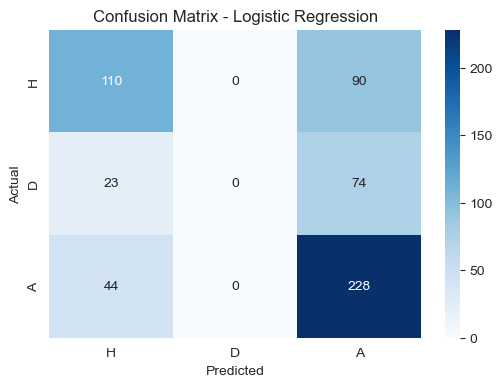

In [18]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["H", "D", "A"],
    yticklabels=["H", "D", "A"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

<H1>Decision Tree</H1>

In [19]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.4780316344463972
              precision    recall  f1-score   support

           A       0.55      0.50      0.52       200
           D       0.22      0.37      0.27        97
           H       0.61      0.50      0.55       272

    accuracy                           0.48       569
   macro avg       0.46      0.46      0.45       569
weighted avg       0.52      0.48      0.49       569



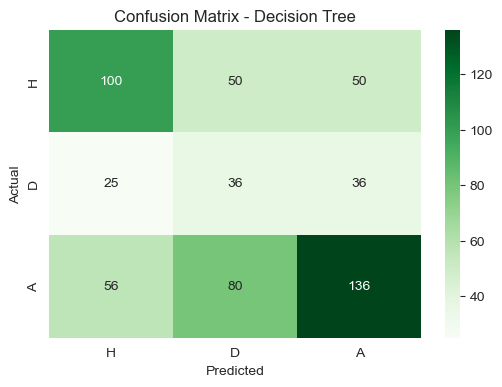

In [20]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["H", "D", "A"],
    yticklabels=["H", "D", "A"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

Reevluating. As I am not that happy with the result

In [21]:
model_dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model_dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
y_pred_dt = model_dt.predict(X_test)

In [23]:
print("Improved Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Improved Decision Tree Accuracy: 0.5588752196836555


In [24]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           A       0.54      0.58      0.56       200
           D       0.00      0.00      0.00        97
           H       0.57      0.74      0.64       272

    accuracy                           0.56       569
   macro avg       0.37      0.44      0.40       569
weighted avg       0.46      0.56      0.51       569



c:\Users\im4284hw\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\im4284hw\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\im4284hw\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

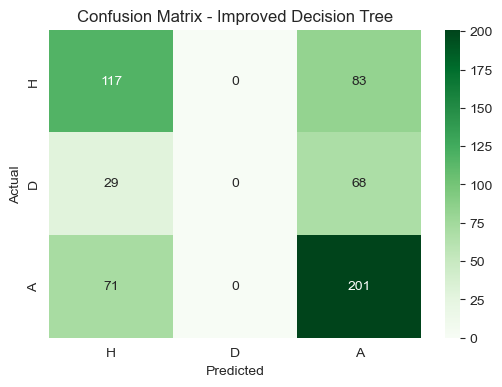

In [25]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["H","D","A"],
    yticklabels=["H","D","A"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Improved Decision Tree")

plt.show()

While the constrained decision tree improved overall accuracy, it completely failed to predict draw outcomes. This highlights the challenge of class imbalance in soccer match prediction, where less frequent outcomes such as draws are often ignored by standard models.

In [26]:
model_dt_balanced = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

model_dt_balanced.fit(X_train, y_train)

y_pred_dt_bal = model_dt_balanced.predict(X_test)

print("Balanced Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt_bal))
print(classification_report(y_test, y_pred_dt_bal))

Balanced Decision Tree Accuracy: 0.5131810193321616
              precision    recall  f1-score   support

           A       0.52      0.70      0.60       200
           D       0.20      0.21      0.21        97
           H       0.65      0.48      0.55       272

    accuracy                           0.51       569
   macro avg       0.46      0.46      0.45       569
weighted avg       0.53      0.51      0.51       569



In [27]:
# cm_dt = confusion_matrix(y_test, y_pred_dt)

# plt.figure(figsize=(6,4))
# sns.heatmap(
#     cm_dt,
#     annot=True,
#     fmt="d",
#     cmap="Greens",
#     xticklabels=["H","D","A"],
#     yticklabels=["H","D","A"]
# )

# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix - Decision Tree")

# plt.show()

<H1>Random Forest</H1>

In [28]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

model_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
# Predict
y_pred_rf = model_rf.predict(X_test)

In [30]:
# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.5869947275922671
              precision    recall  f1-score   support

           A       0.57      0.67      0.62       200
           D       0.27      0.12      0.17        97
           H       0.65      0.69      0.67       272

    accuracy                           0.59       569
   macro avg       0.50      0.49      0.49       569
weighted avg       0.56      0.59      0.57       569



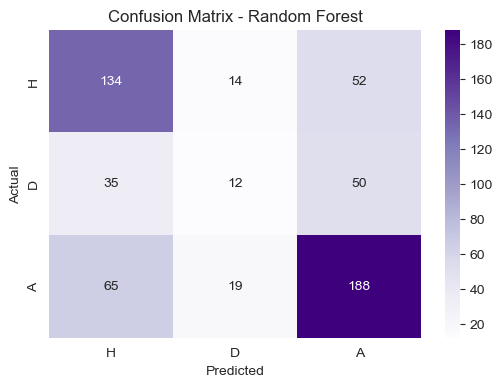

In [31]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["H","D","A"],
    yticklabels=["H","D","A"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

<H1>XGBoost</H1>

In [32]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()

y_train_enc = le_target.fit_transform(y_train)
y_test_enc = le_target.transform(y_test)

In [33]:
# Train model
model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    objective="multi:softmax",
    num_class=3,
    random_state=42
)

model_xgb.fit(X_train, y_train_enc)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [34]:
# Predict
y_pred_xgb = model_xgb.predict(X_test)

In [35]:
# Evaluate 
print("XGBoost Accuracy:", accuracy_score(y_test_enc, y_pred_xgb))

print(classification_report(y_test_enc, y_pred_xgb))

XGBoost Accuracy: 0.648506151142355
              precision    recall  f1-score   support

           0       0.64      0.70      0.67       200
           1       0.32      0.10      0.16        97
           2       0.69      0.81      0.74       272

    accuracy                           0.65       569
   macro avg       0.55      0.54      0.52       569
weighted avg       0.61      0.65      0.62       569



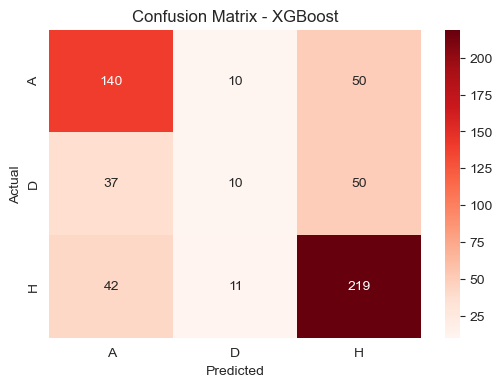

In [36]:
cm_xgb = confusion_matrix(y_test_enc, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["A","D","H"],
    yticklabels=["A","D","H"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")

plt.show()

<h1>Comperison of the plots</h1>

In [37]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Improved Decision Tree",
        "Balanced Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.50,   
        0.48,
        0.56,
        0.51,
        0.59,
        0.65
    ],
    "Draw Recall": [
        0.10,   
        0.37,
        0.00,
        0.21,
        0.12,
        0.10
    ]
})

comparison

,Model,Accuracy,Draw Recall
0,Logistic Regression,0.50,0.10
1,Decision Tree,0.48,0.37
2,Improved Decision Tree,0.56,0.00
3,Balanced Decision Tree,0.51,0.21
4,Random Forest,0.59,0.12
5,XGBoost,0.65,0.10


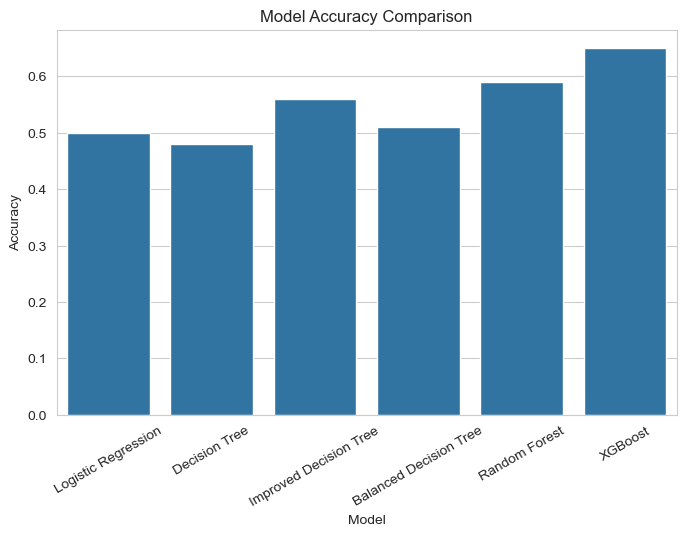

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(data=comparison, x="Model", y="Accuracy")

plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

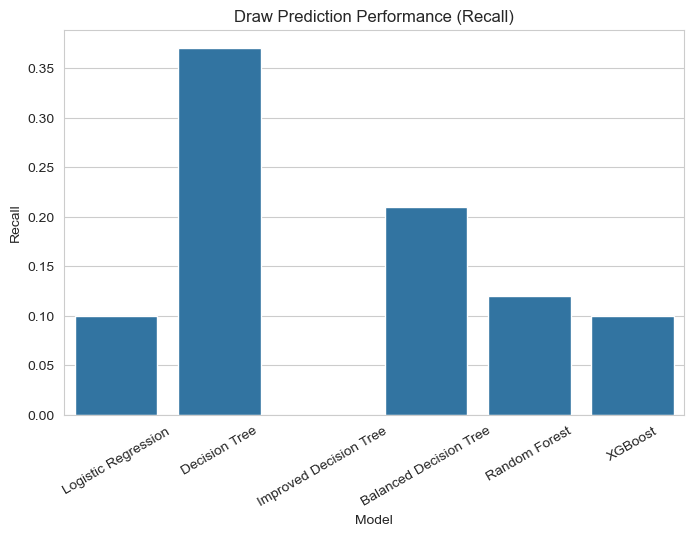

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(data=comparison, x="Model", y="Draw Recall")

plt.xticks(rotation=30)
plt.title("Draw Prediction Performance (Recall)")
plt.ylabel("Recall")

plt.show()

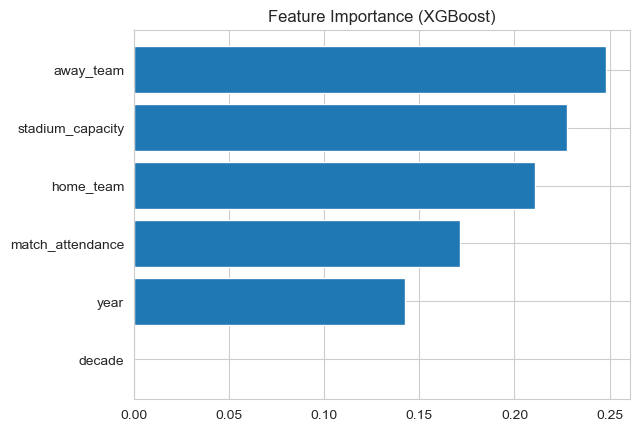

In [40]:
import matplotlib.pyplot as plt

importances = model_xgb.feature_importances_
features = X_train.columns

# Sort the features by importance
sorted_idx = np.argsort(importances)
plt.barh(features[sorted_idx], importances[sorted_idx])
plt.title("Feature Importance (XGBoost)")
plt.show(4)

In [41]:
# comparison of plots between feature importance, home win recall, away win recall, draw recall

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.50,   
        0.51,
        0.59,
        0.65
    ],
    "Recall_H (Home Win)": [
        0.55,  
        0.48,
        0.69,
        0.81
    ],
    "Recall_A (Away Win)": [
        0.50,
        0.70,
        0.67,
        0.70
    ],
    "Recall_D (Draw)": [
        0.10,
        0.21,
        0.12,
        0.10
    ]
})

comparison

,Model,Accuracy,Recall_H (Home Win),Recall_A (Away Win),Recall_D (Draw)
0,Logistic Regression,0.50,0.55,0.50,0.10
1,Decision Tree,0.51,0.48,0.70,0.21
2,Random Forest,0.59,0.69,0.67,0.12
3,XGBoost,0.65,0.81,0.70,0.10


Roc curve of all

In [42]:
# Getting probabilities for all models 
# Logistic Regression
y_prob_lr = model_lr.predict_proba(X_test)

# Decision Tree (balanced)
y_prob_dt = model_dt_balanced.predict_proba(X_test)

# Random Forest
y_prob_rf = model_rf.predict_proba(X_test)

# XGBoost
y_prob_xgb = model_xgb.predict_proba(X_test)

In [43]:
from sklearn.preprocessing import label_binarize

classes = ["A", "D", "H"]
y_test_bin = label_binarize(y_test, classes=classes)

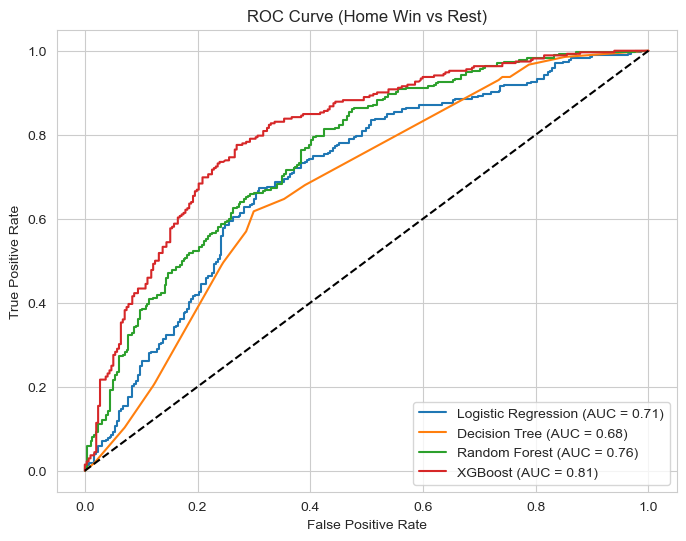

In [44]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": y_prob_lr,
    "Decision Tree": y_prob_dt,
    "Random Forest": y_prob_rf,
    "XGBoost": y_prob_xgb
}

idx = classes.index("H")  # focus on Home Win

for model_name, y_prob in models.items():
    fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob[:, idx])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Home Win vs Rest)")
plt.legend()

plt.show()

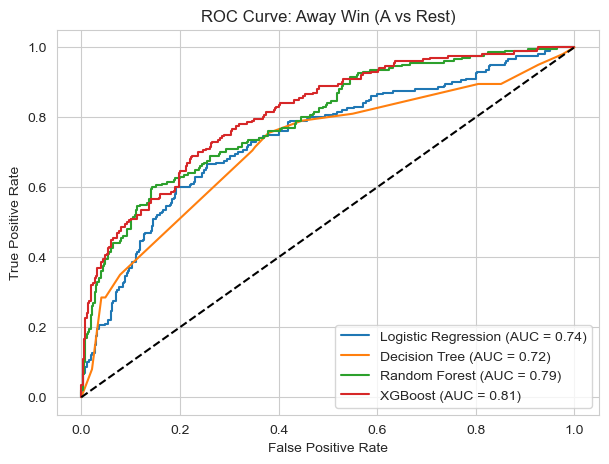

In [45]:
# For Away Win
idx = classes.index("A")

plt.figure(figsize=(7,5))

fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob_lr[:, idx])
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc(fpr,tpr):.2f})")

fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob_dt[:, idx])
plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {auc(fpr,tpr):.2f})")

fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob_rf[:, idx])
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc(fpr,tpr):.2f})")

fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob_xgb[:, idx])
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc(fpr,tpr):.2f})")

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve: Away Win (A vs Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

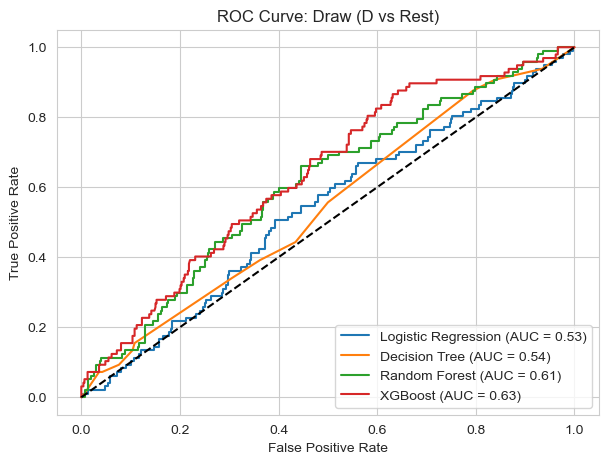

In [46]:
# For Deaw
idx = classes.index("D")

plt.figure(figsize=(7,5))

fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob_lr[:, idx])
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc(fpr,tpr):.2f})")

fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob_dt[:, idx])
plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {auc(fpr,tpr):.2f})")

fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob_rf[:, idx])
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc(fpr,tpr):.2f})")

fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob_xgb[:, idx])
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc(fpr,tpr):.2f})")

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve: Draw (D vs Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")  #it was going to the top left 
plt.show()

For poster quality pics 

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_cm_separate(y_true, y_pred, title):
    
    cm = confusion_matrix(y_true, y_pred, labels=["H", "D", "A"])

    plt.figure(figsize=(8, 5), dpi=300)

    ax = sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        linewidths=2,
        linecolor="black",
        annot_kws={"size": 28, "weight": "bold"}
    )

    ax.set_xticklabels(["H", "D", "A"], fontsize=18, fontname="Arial")
    ax.set_yticklabels(["H", "D", "A"], fontsize=18, fontname="Arial", rotation=0)

    ax.set_xlabel("Predicted", fontsize=20, fontname="Arial", weight="bold")
    ax.set_ylabel("Actual", fontsize=20, fontname="Arial", weight="bold")
    ax.set_title(title, fontsize=30, fontname="Arial", weight="bold", loc="center")

    plt.show()

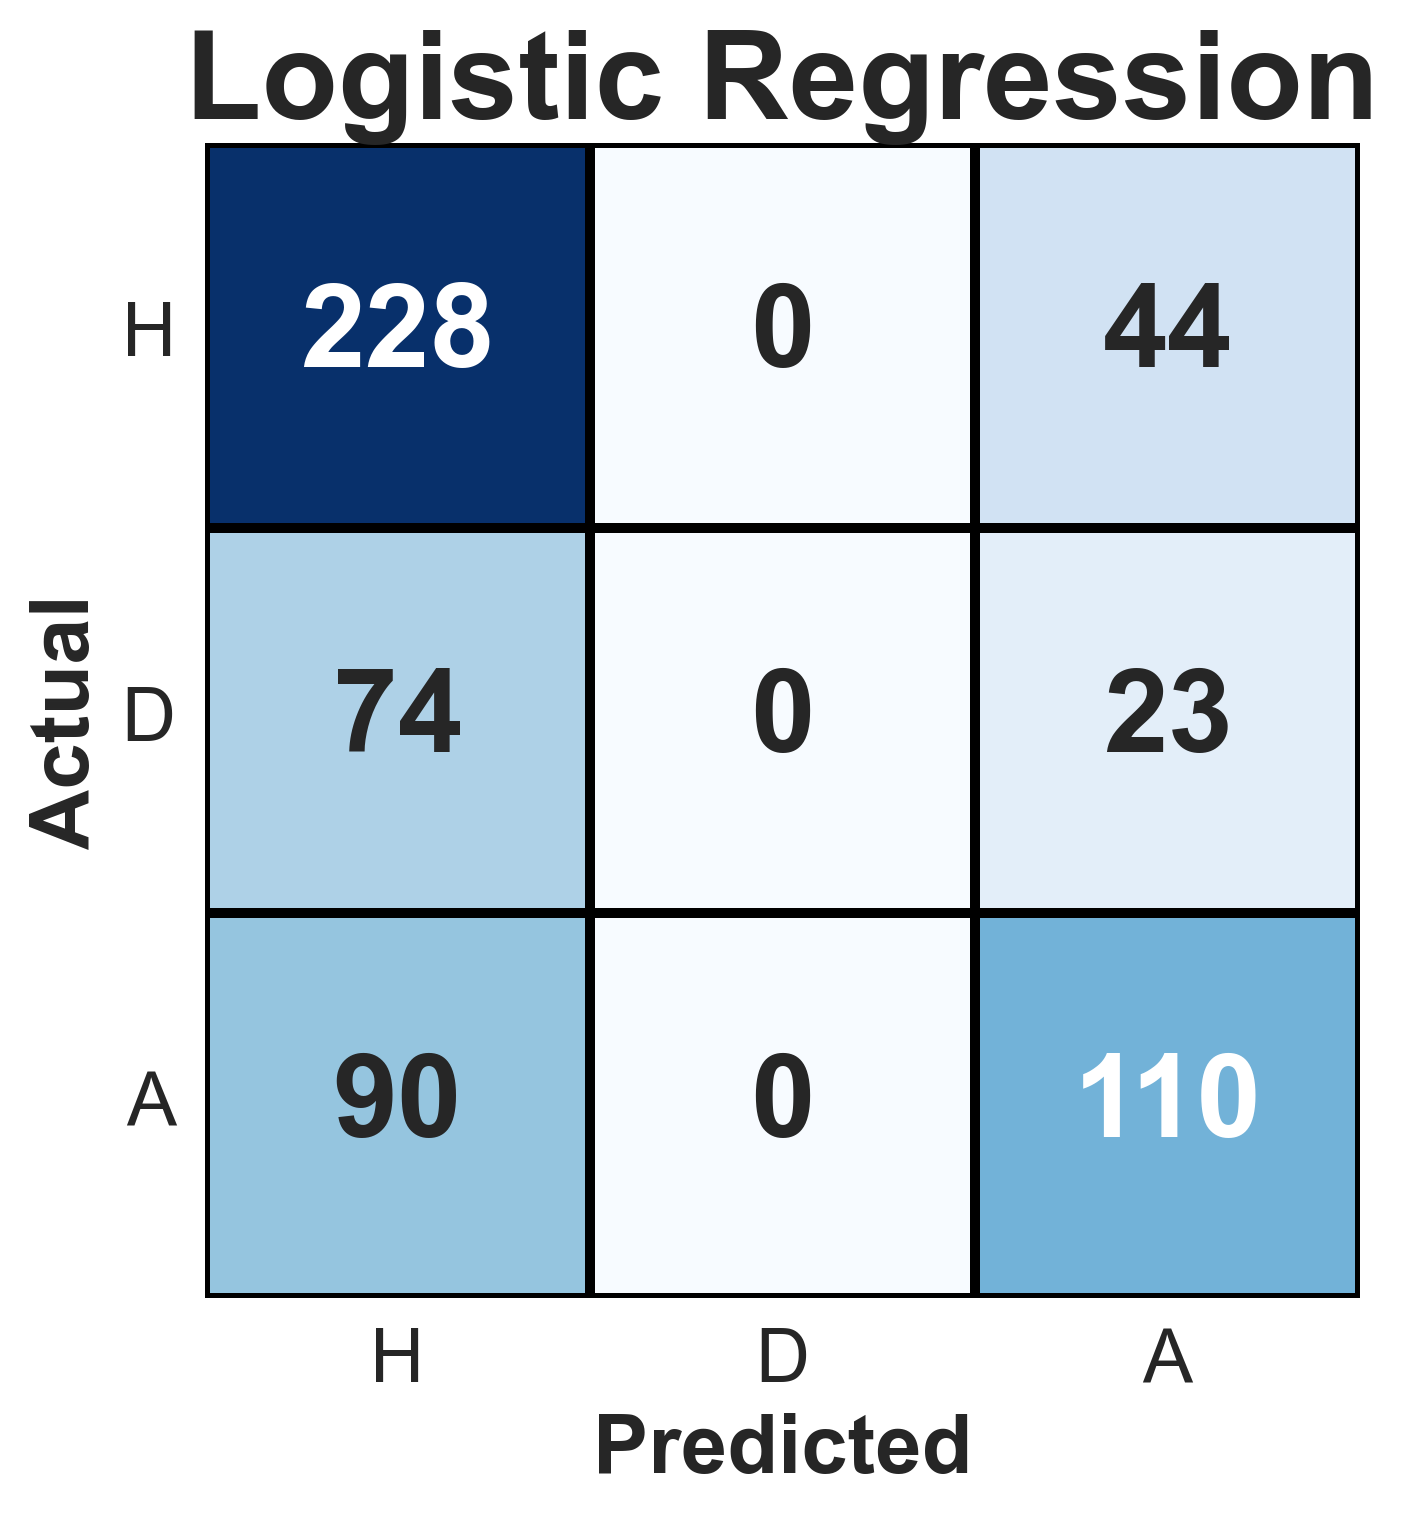

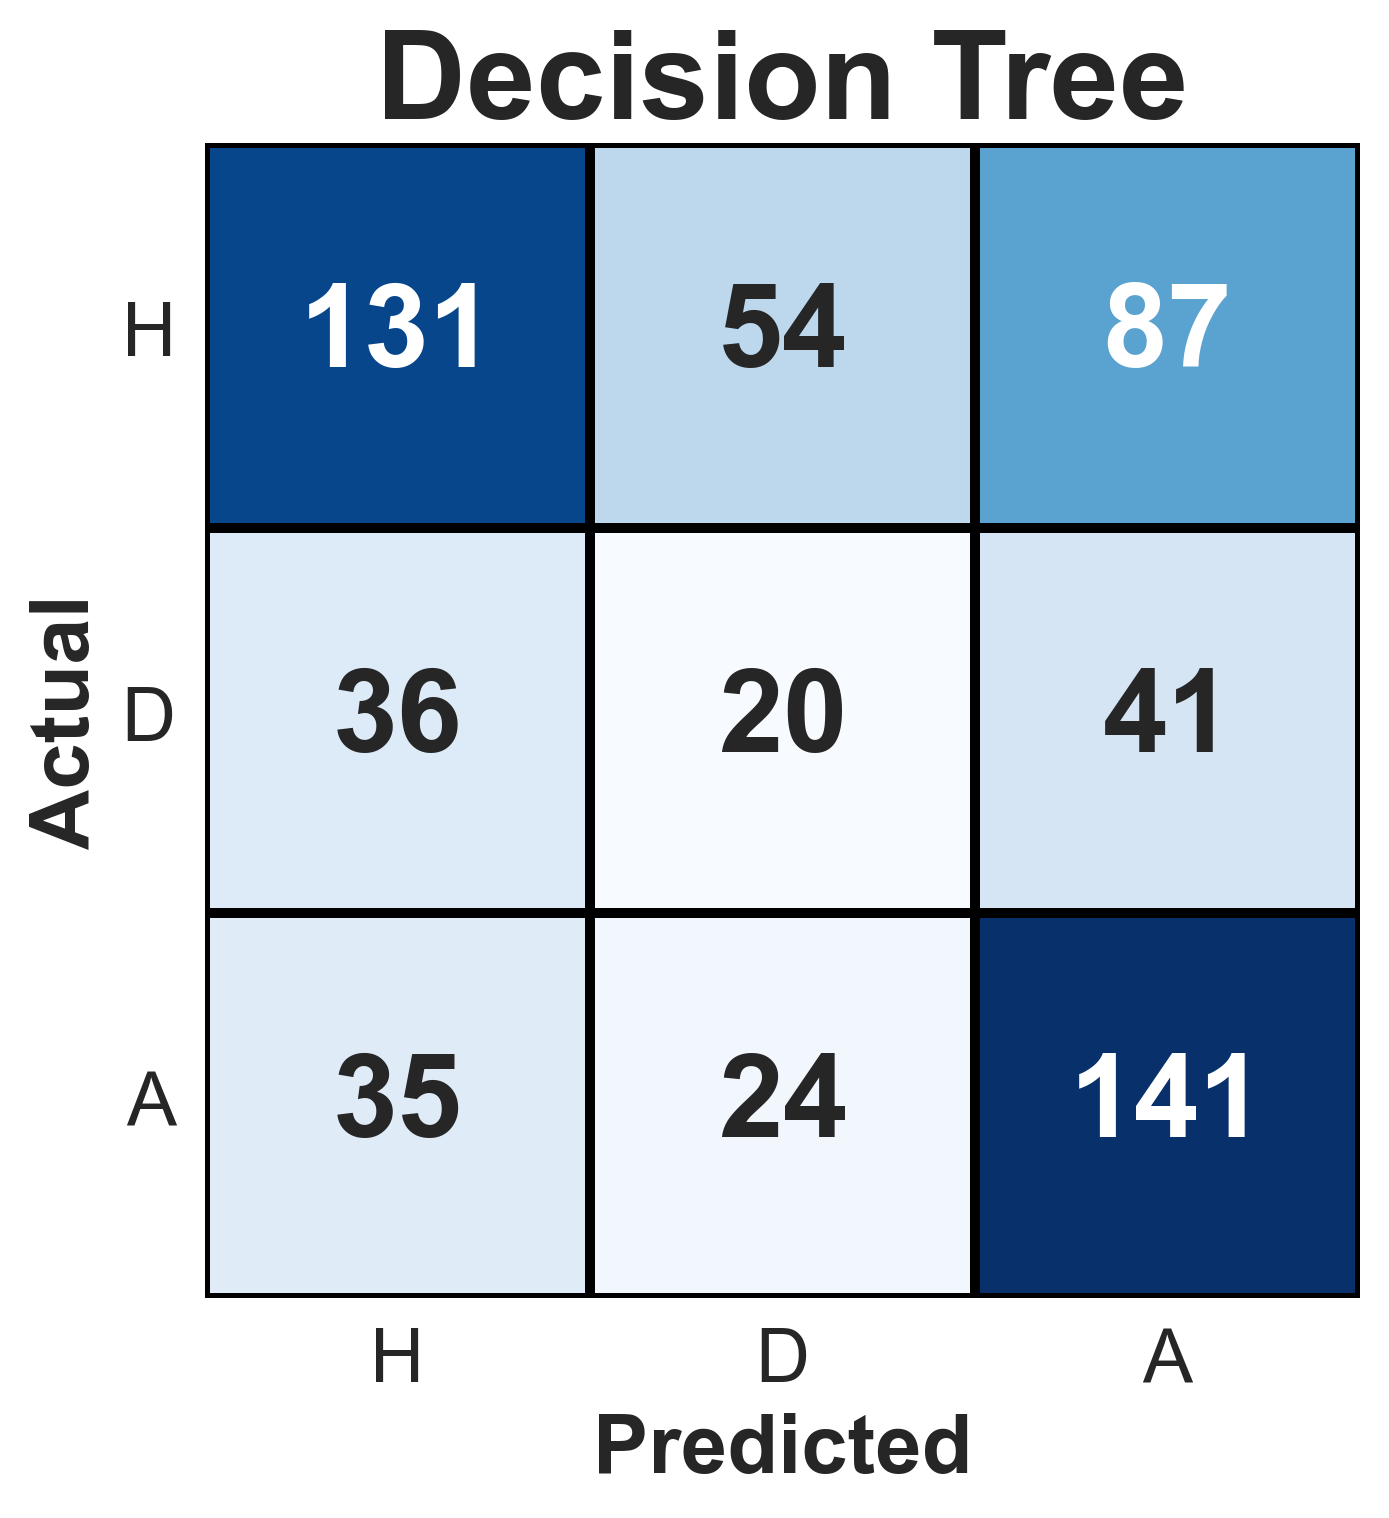

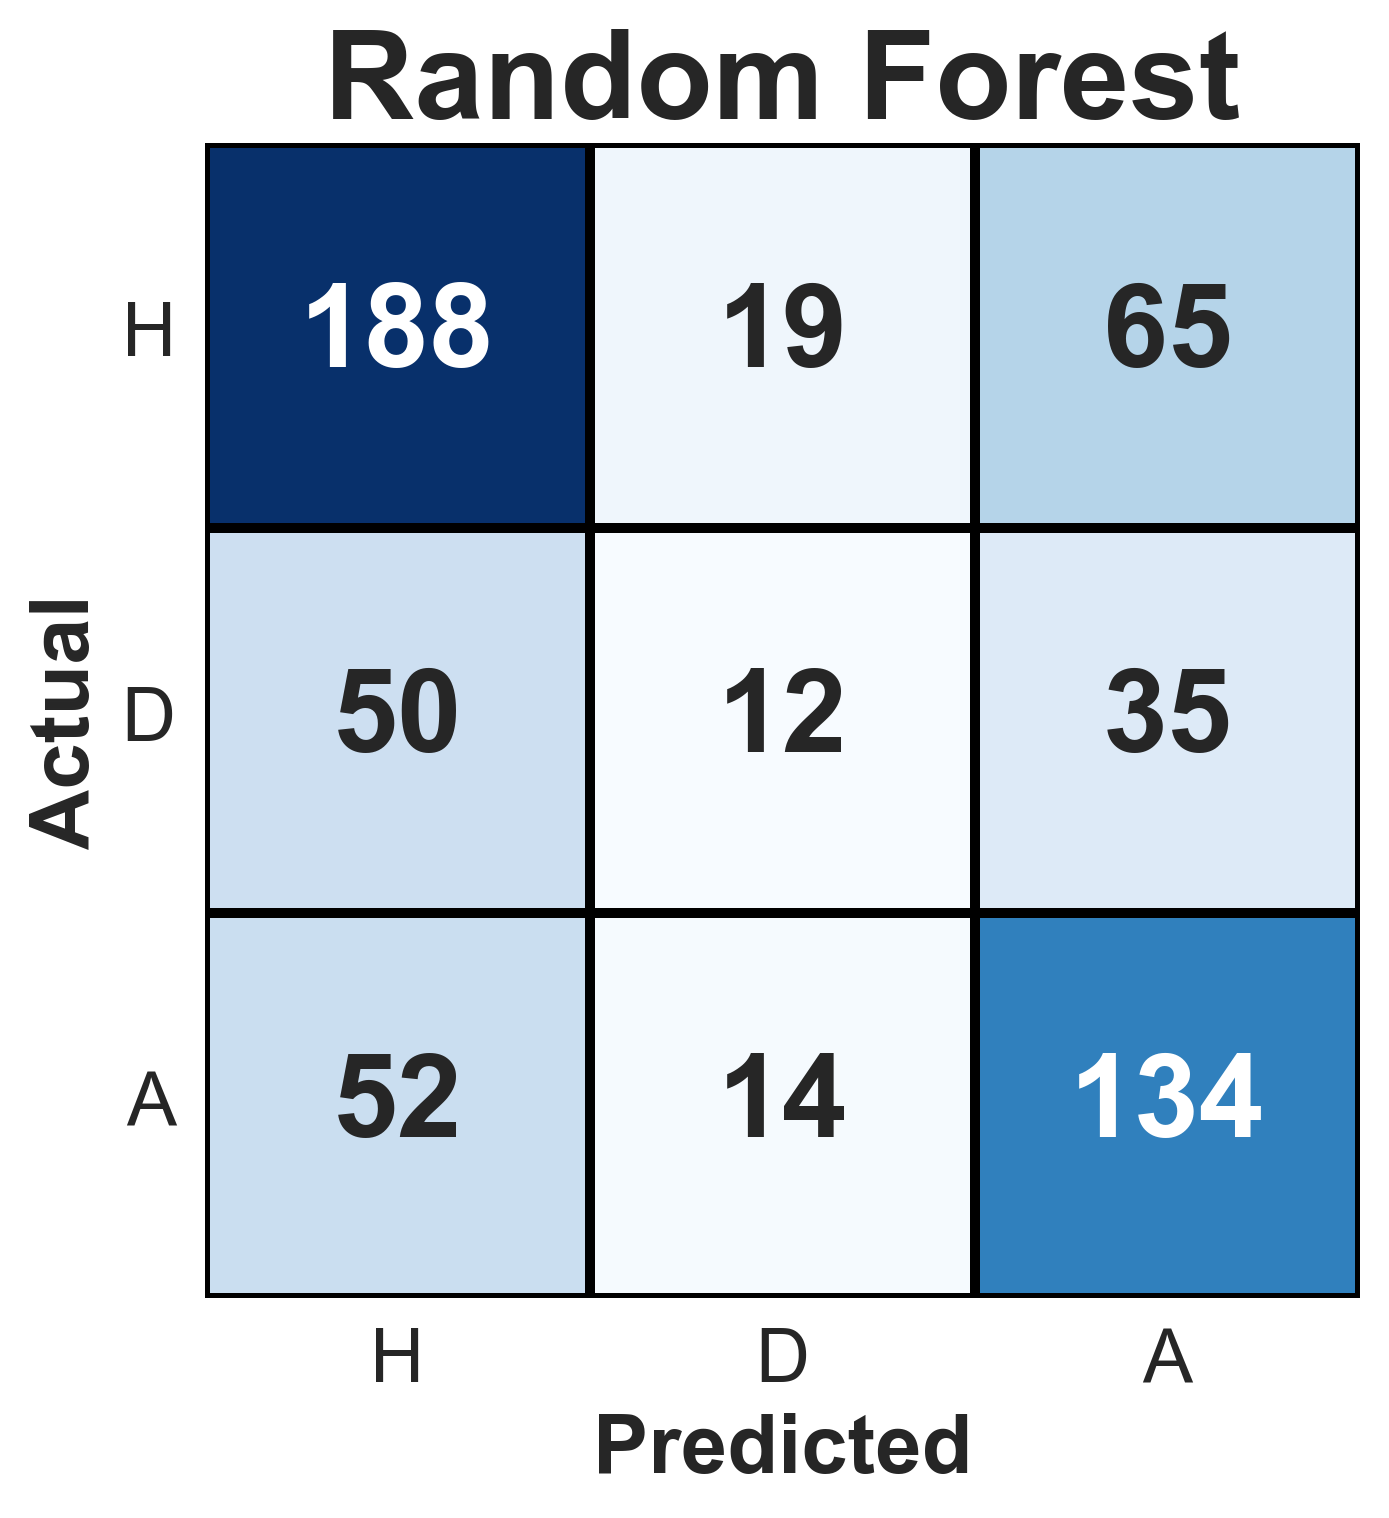

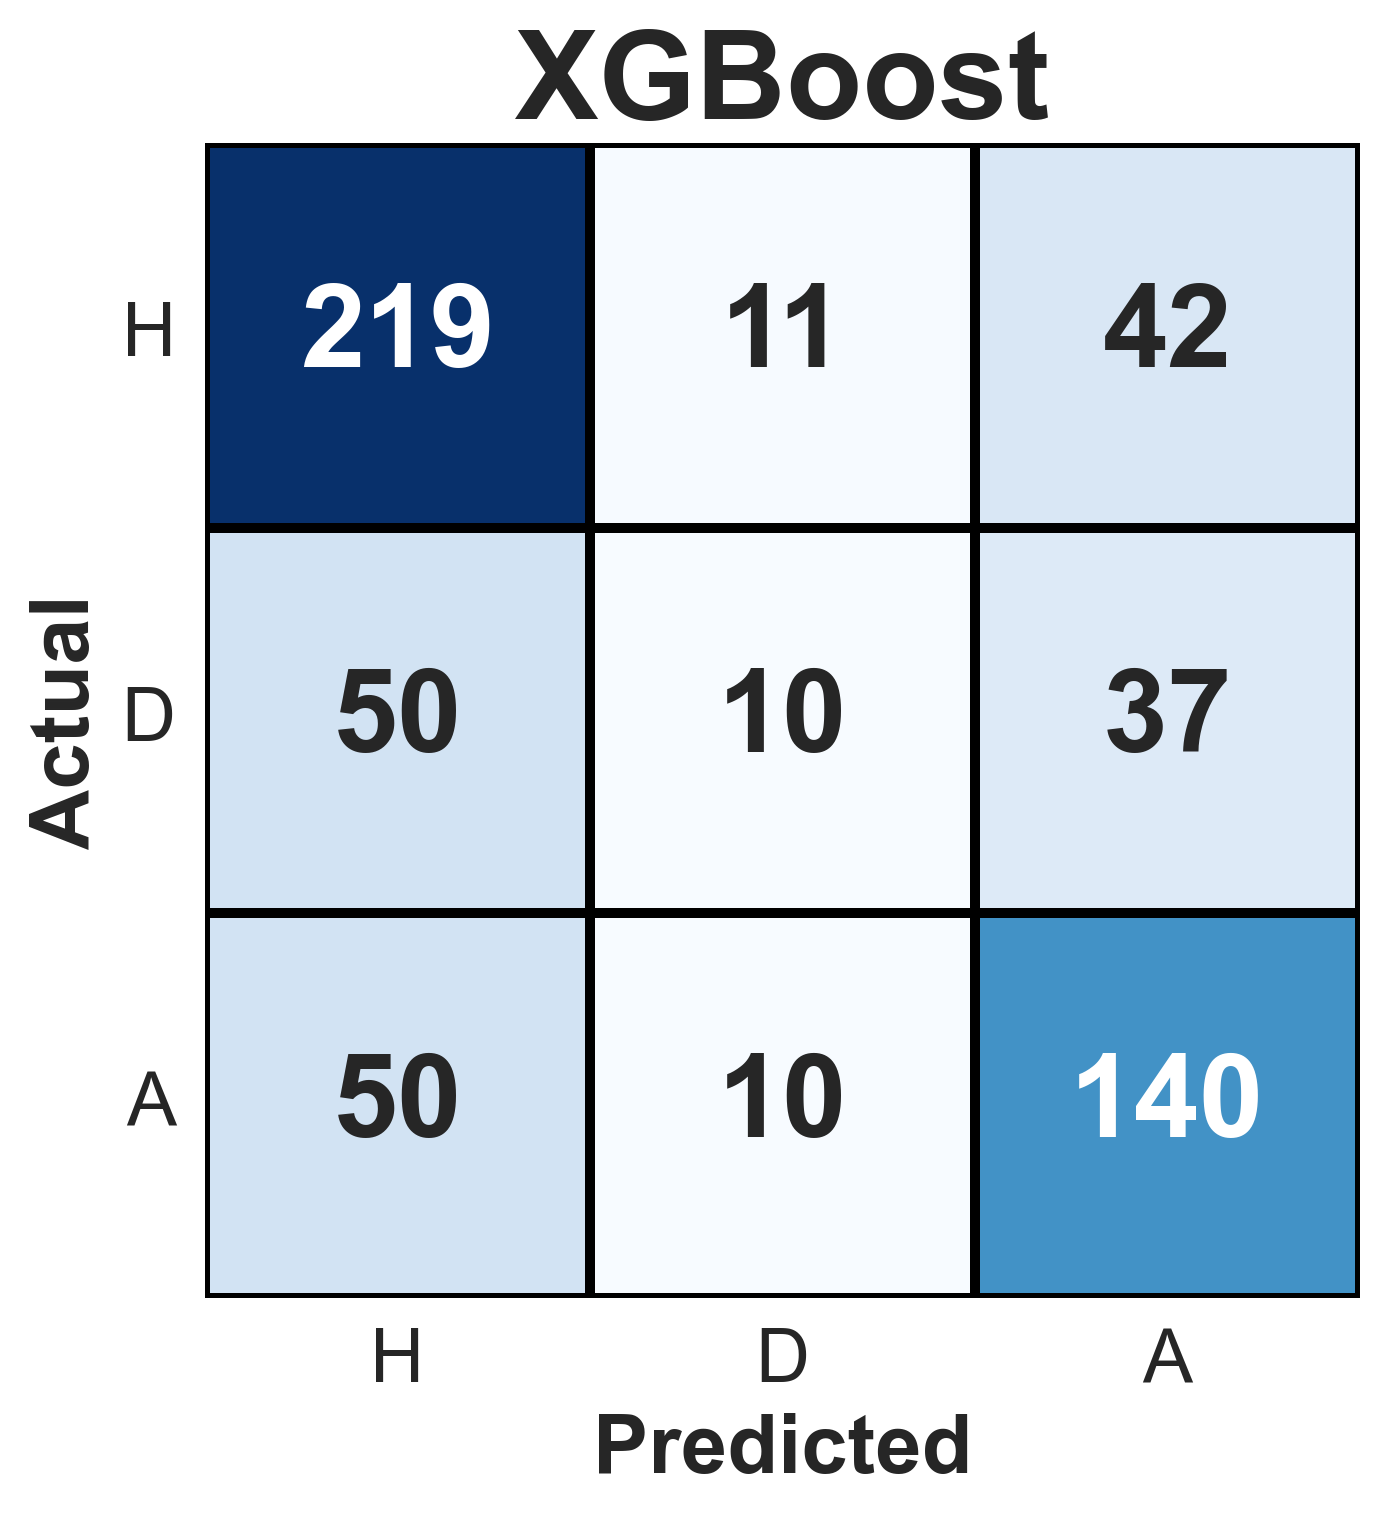

In [49]:
plot_cm_separate(y_test, y_pred, "Logistic Regression")
plot_cm_separate(y_test, y_pred_dt_bal, "Decision Tree")
plot_cm_separate(y_test, y_pred_rf, "Random Forest")

y_pred_xgb_labels = le_target.inverse_transform(y_pred_xgb)
plot_cm_separate(y_test, y_pred_xgb_labels, "XGBoost")

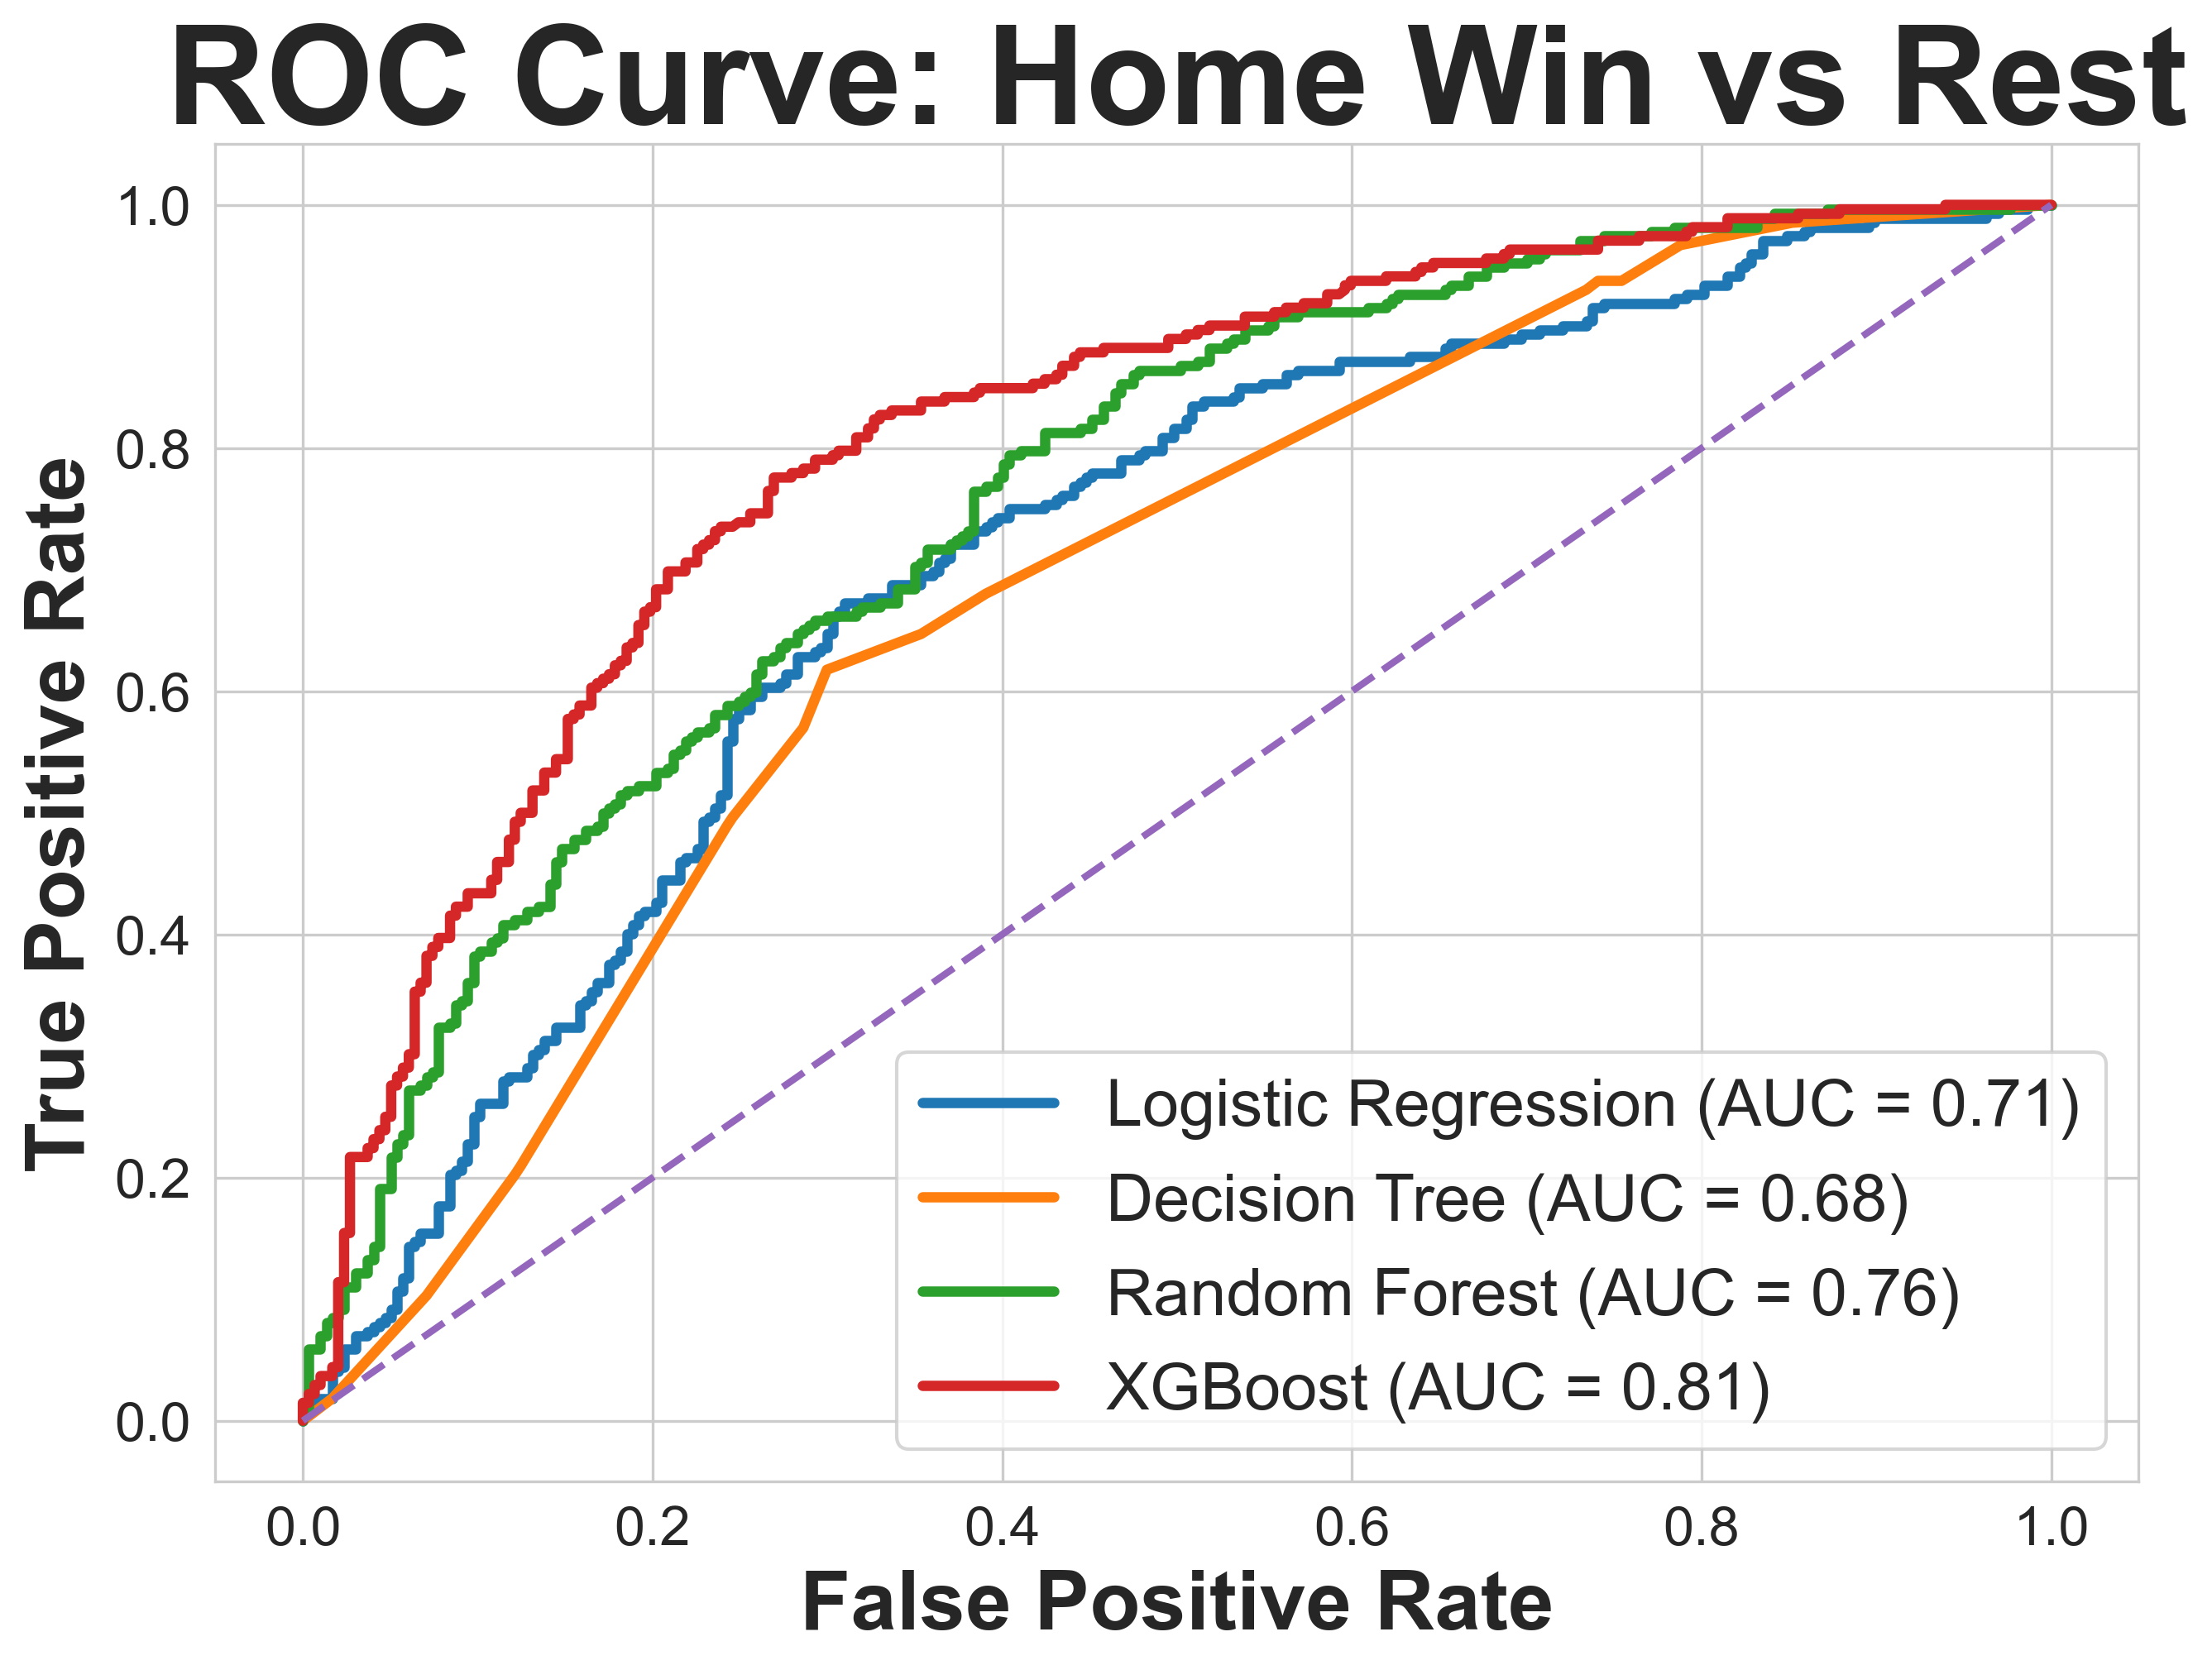

In [50]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Class order
classes = ["A", "D", "H"]

# Binarize true labels
y_test_bin = label_binarize(y_test, classes=classes)

# Index for Home Win
idx = classes.index("H")

plt.figure(figsize=(10, 7), dpi=300)

# Logistic Regression
fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob_lr[:, idx])
plt.plot(fpr, tpr, linewidth=3, label=f"Logistic Regression (AUC = {auc(fpr, tpr):.2f})")

# Decision Tree
fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob_dt[:, idx])
plt.plot(fpr, tpr, linewidth=3, label=f"Decision Tree (AUC = {auc(fpr, tpr):.2f})")

# Random Forest
fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob_rf[:, idx])
plt.plot(fpr, tpr, linewidth=3, label=f"Random Forest (AUC = {auc(fpr, tpr):.2f})")

# XGBoost
fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob_xgb[:, idx])
plt.plot(fpr, tpr, linewidth=3, label=f"XGBoost (AUC = {auc(fpr, tpr):.2f})")

# Reference line
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2)

plt.xlabel("False Positive Rate", fontsize=24, fontname="Arial", weight="bold")
plt.ylabel("True Positive Rate", fontsize=24, fontname="Arial", weight="bold")
plt.title("ROC Curve: Home Win vs Rest", fontsize=40, fontname="Arial", weight="bold", loc="center")

plt.xticks(fontsize=16, fontname="Arial")
plt.yticks(fontsize=16, fontname="Arial")

plt.legend(loc="lower right", fontsize=19)
plt.show()

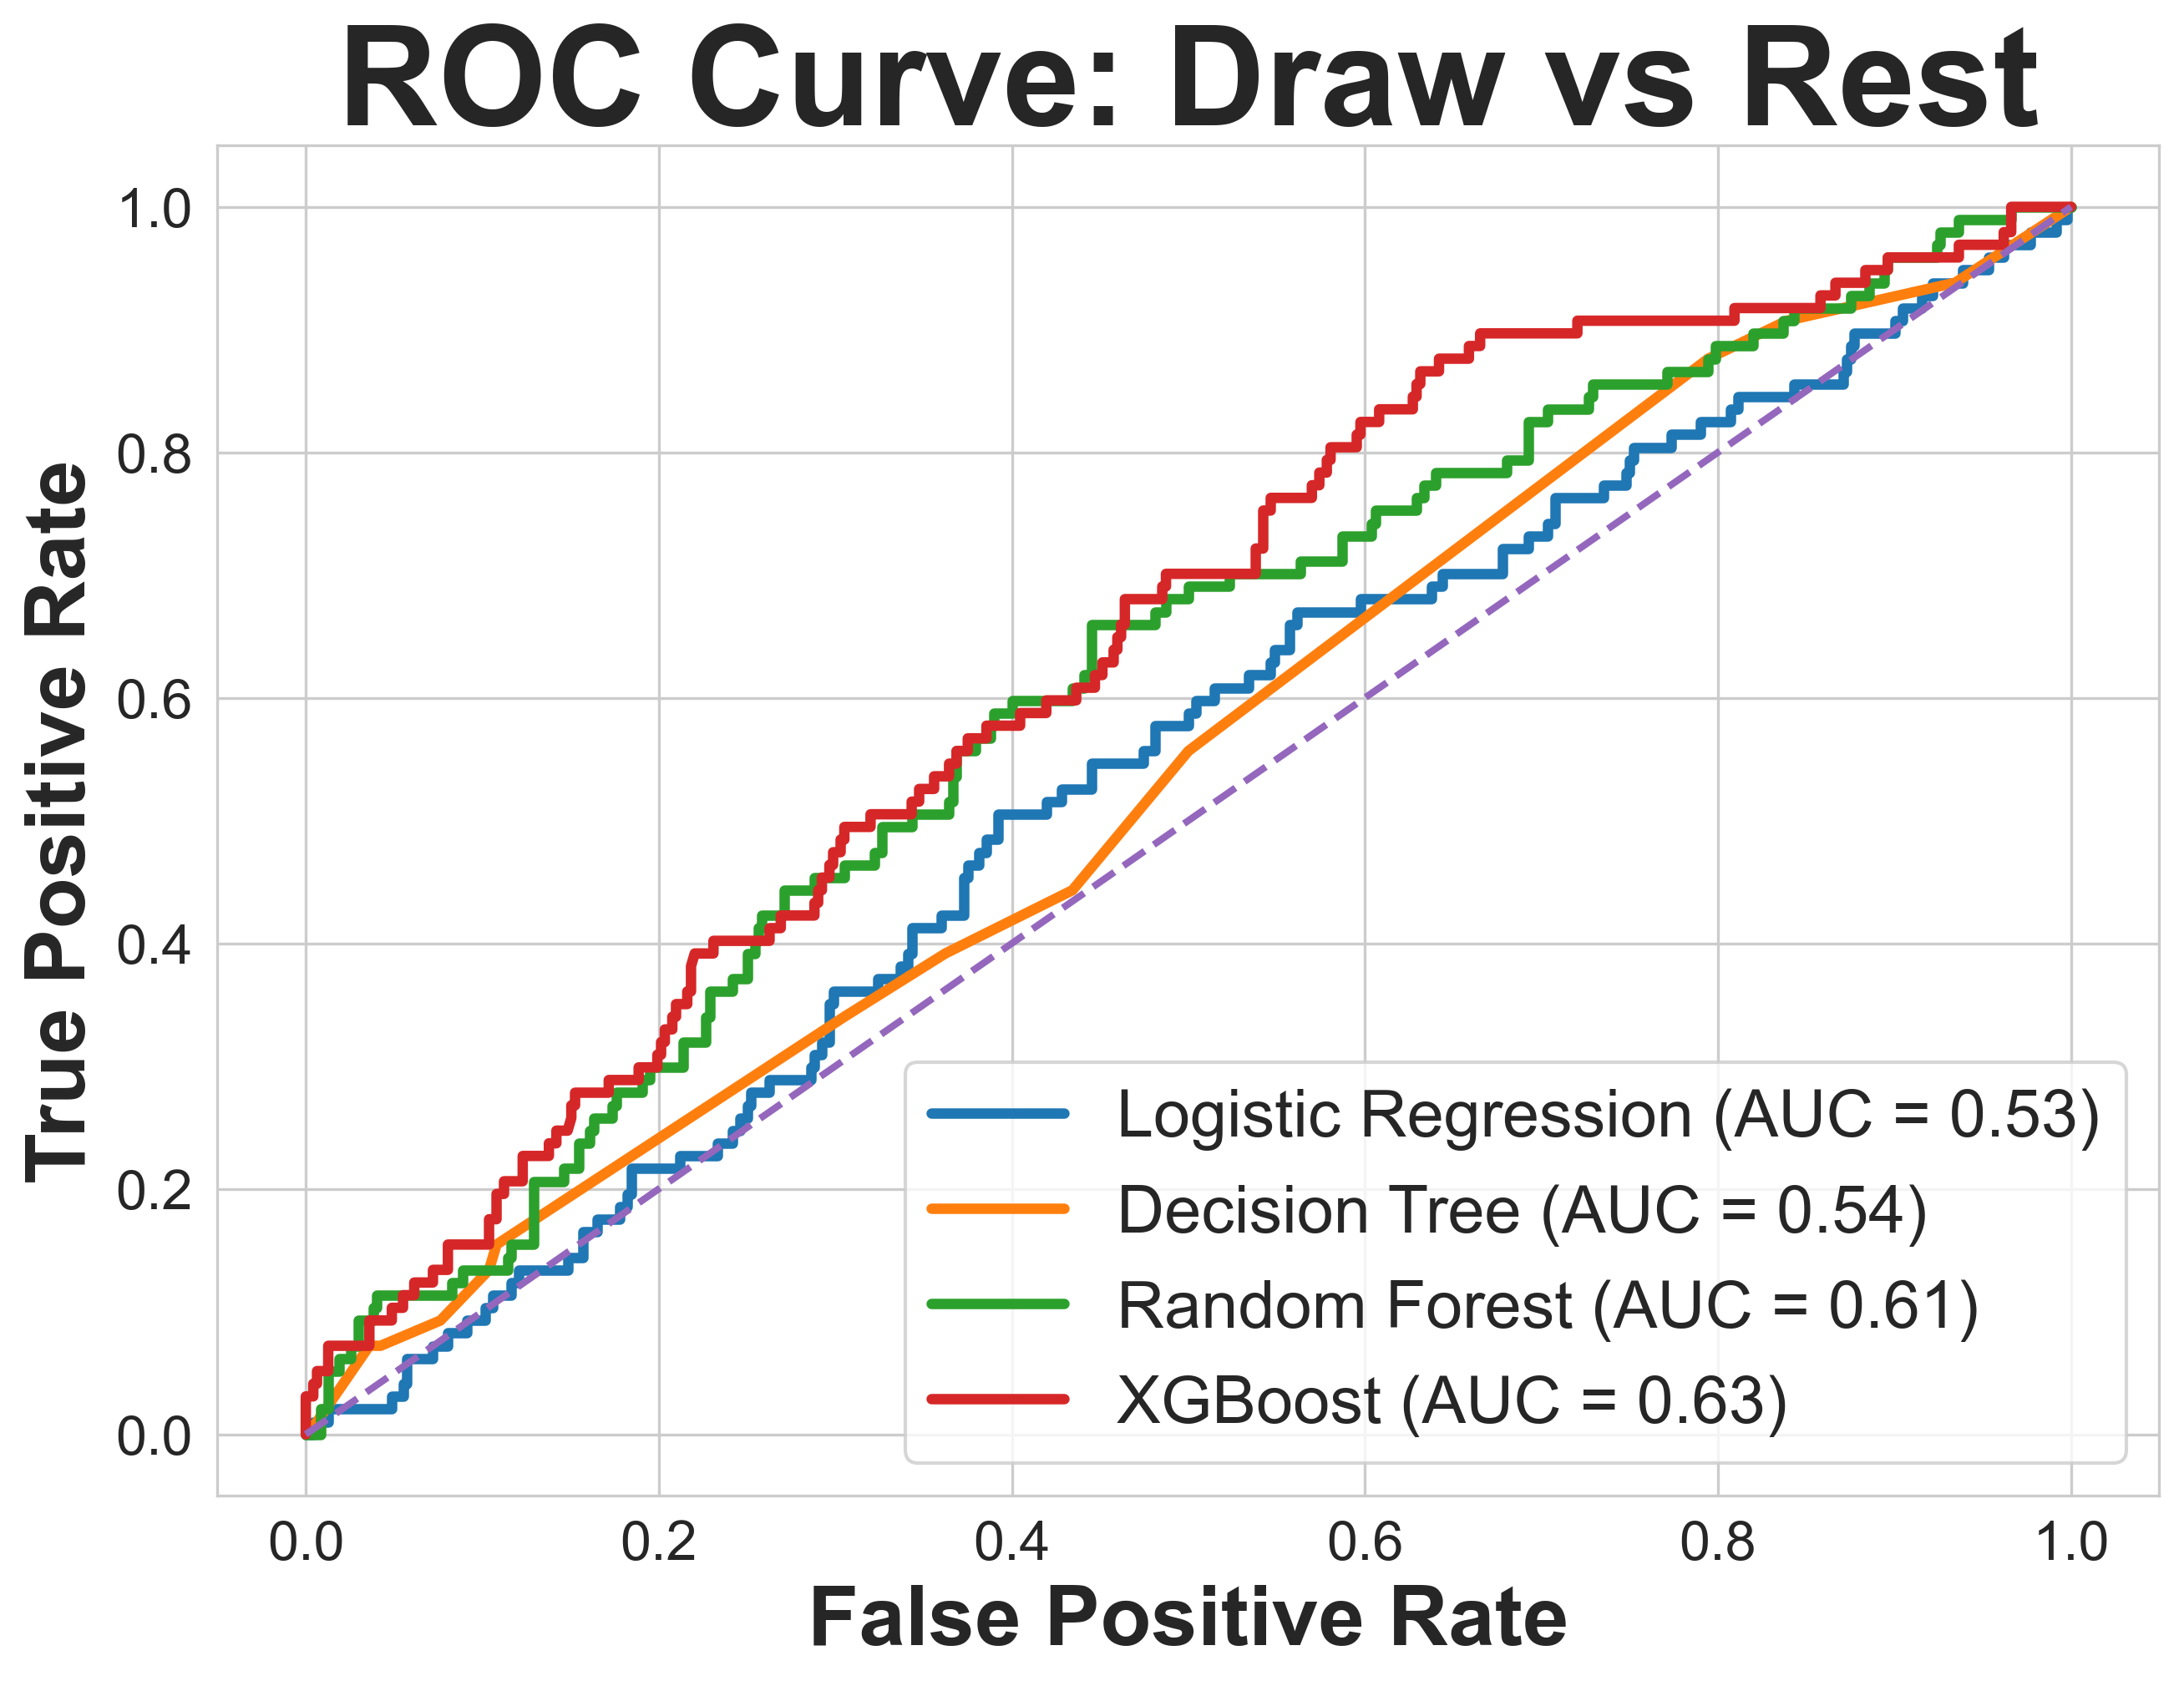

In [51]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Class order
classes = ["A", "D", "H"]

# Binarize true labels
y_test_bin = label_binarize(y_test, classes=classes)

# Index for Draw
idx = classes.index("D")

plt.figure(figsize=(10, 7), dpi=300)

# Logistic Regression
fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob_lr[:, idx])
plt.plot(fpr, tpr, linewidth=3, label=f"Logistic Regression (AUC = {auc(fpr, tpr):.2f})")

# Decision Tree
fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob_dt[:, idx])
plt.plot(fpr, tpr, linewidth=3, label=f"Decision Tree (AUC = {auc(fpr, tpr):.2f})")

# Random Forest
fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob_rf[:, idx])
plt.plot(fpr, tpr, linewidth=3, label=f"Random Forest (AUC = {auc(fpr, tpr):.2f})")

# XGBoost
fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob_xgb[:, idx])
plt.plot(fpr, tpr, linewidth=3, label=f"XGBoost (AUC = {auc(fpr, tpr):.2f})")

# Reference line
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2)

plt.xlabel("False Positive Rate", fontsize=24, fontname="Arial", weight="bold")
plt.ylabel("True Positive Rate", fontsize=24, fontname="Arial", weight="bold")
plt.title("ROC Curve: Draw vs Rest", fontsize=40, fontname="Arial", weight="bold", loc="center")

plt.xticks(fontsize=16, fontname="Arial")
plt.yticks(fontsize=16, fontname="Arial")

plt.legend(loc="lower right", fontsize=19)
plt.show()